This notebooks looks into how the local rate changes with different values for the common envelope efficiency parameter.

### Imports and Definitions

In [1]:
import h5py as h5 
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import tol_colors as tc

import useful_fncs
import utils_from_others
import figure_utils

# plotting imports
# import for axes labels 
plt.rc('text.latex', preamble=r'\usepackage{textgreek}')
plt.rc('font', family='serif')
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif"
})

### Get the results of the merger rate at z = 0 for $\alpha_{CE}$ of 0.25, 0.5, 0.75, 1, 2

In [2]:
# NSNS results
merger_rates_z0_CEalpha025_NSNS = useful_fncs.merger_rate_z0_result_NSNS('/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_NSNS_CE_alpha025/MainRun/COMPAS_Output_wWeights.h5')
merger_rates_z0_CEalpha05_NSNS = useful_fncs.merger_rate_z0_result_NSNS('/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_NSNS_CE_alpha05/MainRun/COMPAS_Output_wWeights.h5')
merger_rates_z0_CEalpha075_NSNS = useful_fncs.merger_rate_z0_result_NSNS('/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_NSNS_CE_alpha075/MainRun/COMPAS_Output_wWeights.h5')
merger_rates_z0_CEalpha1_NSNS = useful_fncs.merger_rate_z0_result_NSNS('/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_NSNS_fid/MainRun/COMPAS_Output_wWeights.h5')
merger_rates_z0_CEalpha2_NSNS = useful_fncs.merger_rate_z0_result_NSNS('/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_NSNS_CE_alpha2/MainRun/COMPAS_Output_wWeights.h5')

In [3]:
# WDWD results
merger_rates_z0_CEalpha025_WDWD = useful_fncs.merger_rate_z0_result_WDWD('/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_MassiveWDWD_NSNS_CE_alpha025/MainRun/COMPAS_Output_wWeights.h5')
merger_rates_z0_CEalpha05_WDWD = useful_fncs.merger_rate_z0_result_WDWD('/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_MassiveWDWD_NSNS_CE_alpha05/MainRun/COMPAS_Output_wWeights.h5')
merger_rates_z0_CEalpha075_WDWD = useful_fncs.merger_rate_z0_result_WDWD('/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_MassiveWDWD_NSNS_CE_alpha075/MainRun/COMPAS_Output_wWeights.h5')
merger_rates_z0_CEalpha1_WDWD = useful_fncs.merger_rate_z0_result_WDWD('/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_MassiveWDWD_NSNS_fid/MainRun/COMPAS_Output_wWeights.h5')
merger_rates_z0_CEalpha2_WDWD = useful_fncs.merger_rate_z0_result_WDWD('/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_MassiveWDWD_NSNS_CE_alpha2/MainRun/COMPAS_Output_wWeights.h5')

### Let's now define the different variations we have

In [4]:
cowdwd_SNe_Ia  = [merger_rates_z0_CEalpha025_WDWD[0],merger_rates_z0_CEalpha05_WDWD[0],merger_rates_z0_CEalpha075_WDWD[0],merger_rates_z0_CEalpha1_WDWD[0],merger_rates_z0_CEalpha2_WDWD[0]]
mchan_SNe_Ia  = [merger_rates_z0_CEalpha025_WDWD[1],merger_rates_z0_CEalpha05_WDWD[1],merger_rates_z0_CEalpha075_WDWD[1],merger_rates_z0_CEalpha1_WDWD[1],merger_rates_z0_CEalpha2_WDWD[1]]
violent_merger_unequal_rates = [merger_rates_z0_CEalpha025_WDWD[2],merger_rates_z0_CEalpha05_WDWD[2],merger_rates_z0_CEalpha075_WDWD[2],merger_rates_z0_CEalpha1_WDWD[2],merger_rates_z0_CEalpha2_WDWD[2]]
violent_merger_equal_rates = [merger_rates_z0_CEalpha025_WDWD[3],merger_rates_z0_CEalpha05_WDWD[3],merger_rates_z0_CEalpha075_WDWD[3],merger_rates_z0_CEalpha1_WDWD[3],merger_rates_z0_CEalpha2_WDWD[3]]
rates_HVS  = [merger_rates_z0_CEalpha025_WDWD[4],merger_rates_z0_CEalpha05_WDWD[4],merger_rates_z0_CEalpha075_WDWD[4],merger_rates_z0_CEalpha1_WDWD[4],merger_rates_z0_CEalpha2_WDWD[4]]
nsns_rates  = [merger_rates_z0_CEalpha025_NSNS,merger_rates_z0_CEalpha05_NSNS,merger_rates_z0_CEalpha075_NSNS,merger_rates_z0_CEalpha1_NSNS,merger_rates_z0_CEalpha2_NSNS]

Text(1.5, 10, 'LVK Observations')

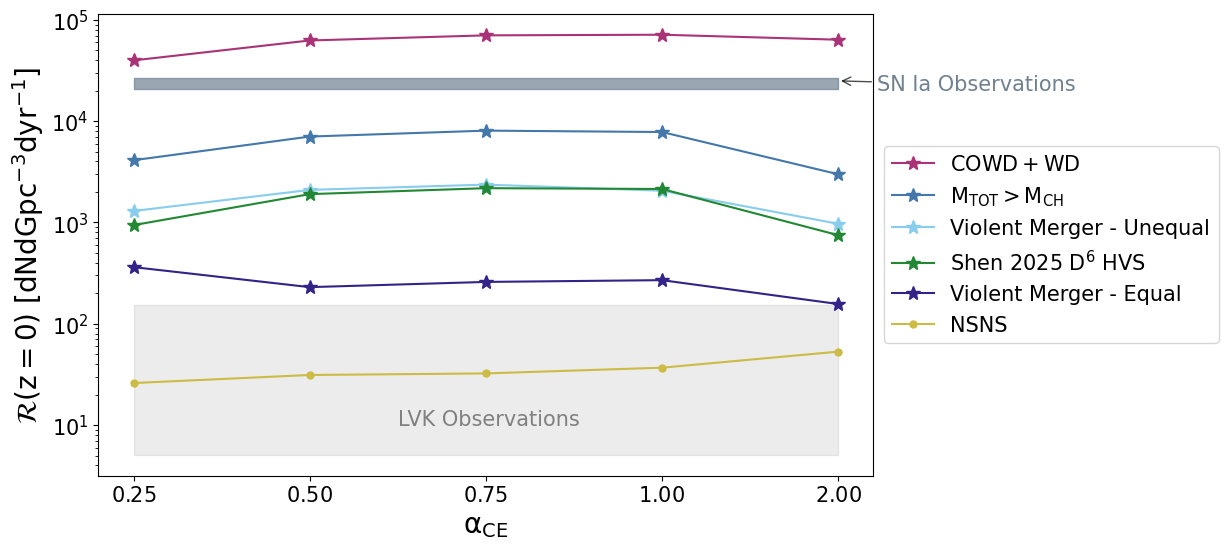

In [10]:
###### we want all of the of SN to have the same color marker
markersize = 10
fig, ax = plt.subplots(figsize = (10,6))
# cset = tc.dark
cset_mu = tc.muted
cset_br = tc.bright

x_positions = [0, 1, 2, 3, 4]
ax.plot(x_positions,cowdwd_SNe_Ia,'*', linestyle='-',label=r'$\mathrm{COWD + WD}$', color=cset_br.purple,markersize = markersize)
ax.plot(x_positions,mchan_SNe_Ia,'*', linestyle='-', label=r'$\mathrm{M_{TOT}>M_{CH}}$', color=cset_br.blue,markersize = markersize)
ax.plot(x_positions,violent_merger_unequal_rates,'*', linestyle='-', label=r'Violent Merger - Unequal', color=cset_mu.cyan,markersize = markersize)
ax.plot(x_positions,rates_HVS,'*', linestyle='-', label=r'Shen 2025 $\mathrm{D^6}$ HVS', color=cset_br.green,markersize = markersize)
ax.plot(x_positions,violent_merger_equal_rates,'*', linestyle='-', label='Violent Merger - Equal', color=cset_mu.indigo,markersize = markersize)
ax.plot(x_positions,nsns_rates,'.', linestyle='-', label='NSNS', color=cset_br.yellow,markersize = markersize)

h_little = 0.6766

## Briel et al 2022 rates at z = 0
ax.fill_between([min(x_positions),max(x_positions)], 
                (0.77-0.10)*(10**5)*(h_little**3),
                (0.77+0.10)*(10**5)*(h_little**3), 
                alpha=0.70, 
                color="slategrey")

### NNS Observed rate
ax.fill_between([min(x_positions),max(x_positions)], 
                5.1,
                154.7, 
                alpha=0.15, 
                color="grey")

# axes labels 
ax.set_yscale('log')
ax.set_ylabel(r"$\mathcal{R}$($\mathrm{z=0}$) [$\mathrm{dNdGpc^{-3}dyr^{-1}}$]",fontsize=20)
ax.set_xlabel(r"$\mathrm{\alpha_{CE}}$", fontsize = 20)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=15)
ax.set_xticks(x_positions, [r"$\mathrm{0.25}$", r"$\mathrm{0.50}$", r"$\mathrm{0.75}$", r"$\mathrm{1.00}$", r"$\mathrm{2.00}$"], fontsize=15);
ax.tick_params(axis='y', labelsize=15);

ax.annotate("SN Ia Observations", xy=(4, 2.5*10**4), xytext=(4.22, 2*10**4), annotation_clip=False, fontsize=15, color = 'slategrey', arrowprops=dict(facecolor='slategrey', alpha=0.7,arrowstyle='->'))
ax.annotate("LVK Observations", xy=(1.5, 10), fontsize=15, color='grey')#, arrowprops=dict(facecolor='slategrey', alpha=0.7,arrowstyle='->'))

# plt.savefig("../figures/CEalpha_variatrions_sweep.png",bbox_inches='tight',pad_inches=0.2)

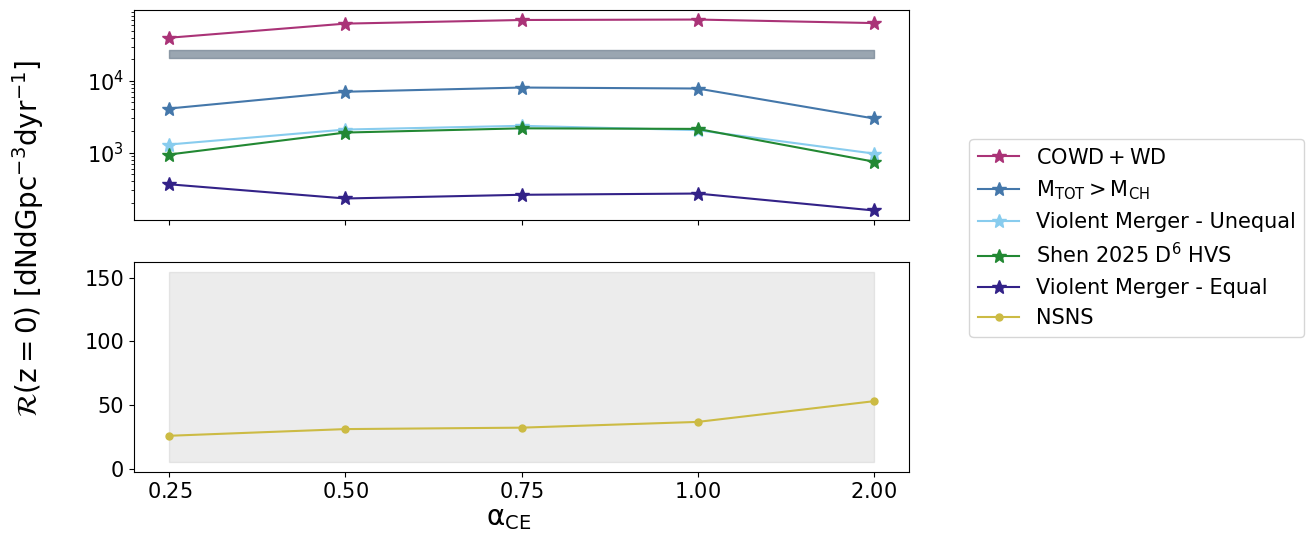

In [8]:
# we want all of the of SN to have the same color marker
markersize = 10
fig, ax = plt.subplots(2, 1, figsize = (10,6), sharex=True)
cset = tc.dark
cset_l = tc.light

x_positions = [0, 1, 2, 3, 4]
ax[0].plot(x_positions,cowdwd_SNe_Ia,'*', linestyle='-',label=r'$\mathrm{COWD + WD}$', color=cset_br.purple,markersize = markersize)
ax[0].plot(x_positions,mchan_SNe_Ia,'*', linestyle='-', label=r'$\mathrm{M_{TOT}>M_{CH}}$', color=cset_br.blue,markersize = markersize)
ax[0].plot(x_positions,violent_merger_unequal_rates,'*', linestyle='-', label=r'Violent Merger - Unequal', color=cset_mu.cyan,markersize = markersize)
ax[0].plot(x_positions,rates_HVS,'*', linestyle='-', label=r'Shen 2025 $\mathrm{D^6}$ HVS', color=cset_br.green,markersize = markersize)
ax[0].plot(x_positions,violent_merger_equal_rates,'*', linestyle='-', label='Violent Merger - Equal', color=cset_mu.indigo,markersize = markersize)
ax[1].plot(x_positions,nsns_rates,'.', linestyle='-', label='NSNS', color=cset_br.yellow,markersize = markersize)

h_little = 0.6766

## Briel et al 2022 rates at z = 0
ax[0].fill_between([min(x_positions),max(x_positions)], 
                (0.77-0.10)*(10**5)*(h_little**3),
                (0.77+0.10)*(10**5)*(h_little**3), 
                alpha=0.70, 
                color="slategrey")

### NNS Observed rate
ax[1].fill_between([min(x_positions),max(x_positions)], 
                5.1,
                154.7, 
                alpha=0.15, 
                color="grey")

# axes labels 
ax[0].set_yscale('log')
fig.supylabel(r"$\mathcal{R}$($\mathrm{z=0}$) [$\mathrm{dNdGpc^{-3}dyr^{-1}}$]",fontsize=20, x=0.001)
fig.supxlabel(r"$\mathrm{\alpha_{CE}}$", fontsize = 20)
fig.legend(loc='center left', bbox_to_anchor=(0.95, 0.5), fontsize=15)

ax[1].set_xticks(x_positions, [r"$\mathrm{0.25}$", r"$\mathrm{0.50}$", r"$\mathrm{0.75}$", r"$\mathrm{1.00}$", r"$\mathrm{2.00}$"], fontsize=15);

ax[0].tick_params(axis='y', labelsize=15);
ax[1].tick_params(axis='y', labelsize=15);
# ax2.tick_params(labelbottom=True)

# plt.savefig("../figures/CEalpha_variatrions_sweep_stacked.png",bbox_inches='tight',pad_inches=0.2)

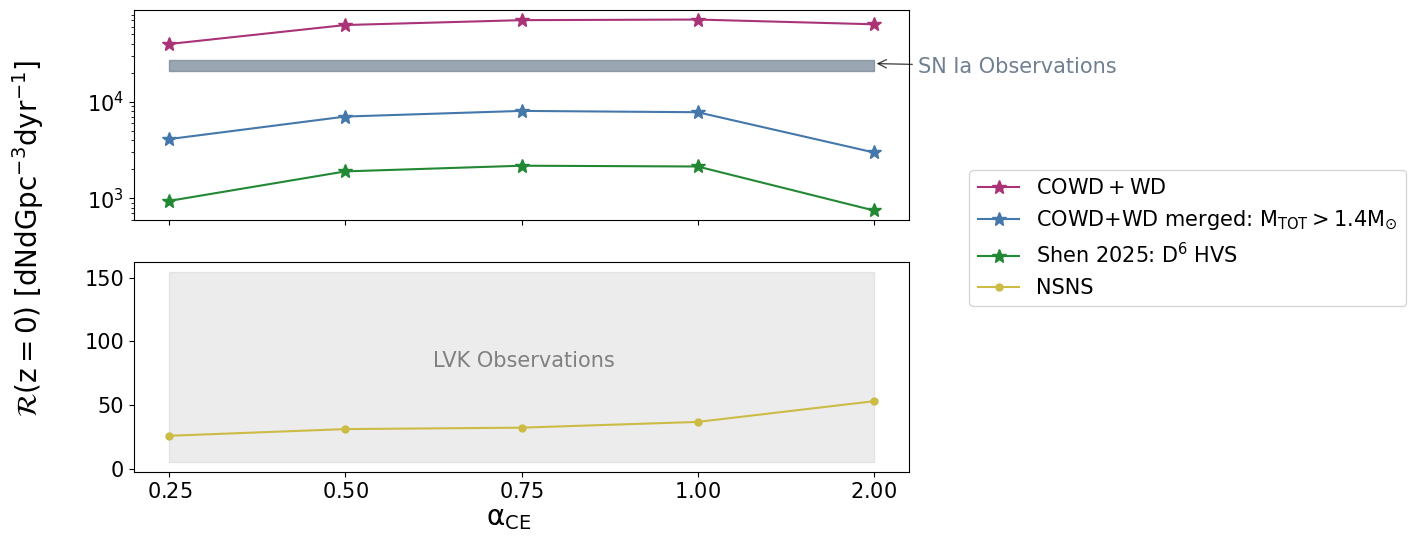

In [9]:
# we want all of the of SN to have the same color marker
markersize = 10
fig, ax = plt.subplots(2, 1, figsize = (10,6), sharex=True)
cset = tc.dark
cset_l = tc.light

x_positions = [0, 1, 2, 3, 4]
ax[0].plot(x_positions,cowdwd_SNe_Ia,'*', linestyle='-',label=r'$\mathrm{COWD + WD}$', color=cset_br.purple,markersize = markersize)
ax[0].plot(x_positions,mchan_SNe_Ia,'*', linestyle='-', label=r'COWD+WD merged: $\rm{M_{TOT}}>1.4\rm{M_{\odot}}$', color=cset_br.blue,markersize = markersize)
ax[0].plot(x_positions,rates_HVS,'*', linestyle='-', label='Shen 2025: $\mathrm{D^6}$ HVS', color=cset_br.green,markersize = markersize)
ax[1].plot(x_positions,nsns_rates,'.', linestyle='-', label='NSNS', color=cset_br.yellow,markersize = markersize)

h_little = 0.6766

## Briel et al 2022 rates at z = 0
ax[0].fill_between([min(x_positions),max(x_positions)], 
                (0.77-0.10)*(10**5)*(h_little**3),
                (0.77+0.10)*(10**5)*(h_little**3), 
                alpha=0.70, 
                color="slategrey")

### NNS Observed rate
ax[1].fill_between([min(x_positions),max(x_positions)], 
                5.1,
                154.7, 
                alpha=0.15, 
                color="grey")

# axes labels 
ax[0].set_yscale('log')
fig.supylabel(r"$\mathcal{R}$($\mathrm{z=0}$) [$\mathrm{dNdGpc^{-3}dyr^{-1}}$]",fontsize=20, x=0.001)
fig.supxlabel(r"$\mathrm{\alpha_{CE}}$", fontsize = 20)
fig.legend(loc='center left', bbox_to_anchor=(0.95, 0.5), fontsize=15)

ax[1].set_xticks(x_positions, [r"$\mathrm{0.25}$", r"$\mathrm{0.50}$", r"$\mathrm{0.75}$", r"$\mathrm{1.00}$", r"$\mathrm{2.00}$"], fontsize=15);

ax[0].tick_params(axis='y', labelsize=15);
ax[1].tick_params(axis='y', labelsize=15);
# ax2.tick_params(labelbottom=True)

ax[0].annotate("SN Ia Observations", xy=(4, 2.5*10**4), xytext=(4.25, 2*10**4), annotation_clip=False, fontsize=15, color = 'slategrey', arrowprops=dict(facecolor='slategrey', alpha=0.7,arrowstyle='->'))
ax[1].annotate("LVK Observations", xy=(1.5, 80), fontsize=15, color='grey')#, arrowprops=dict(facecolor='slategrey', alpha=0.7,arrowstyle='->'))


# plt.savefig("../figures/CEalpha_variatrions_sweep_stacked.png",bbox_inches='tight',pad_inches=0.2)

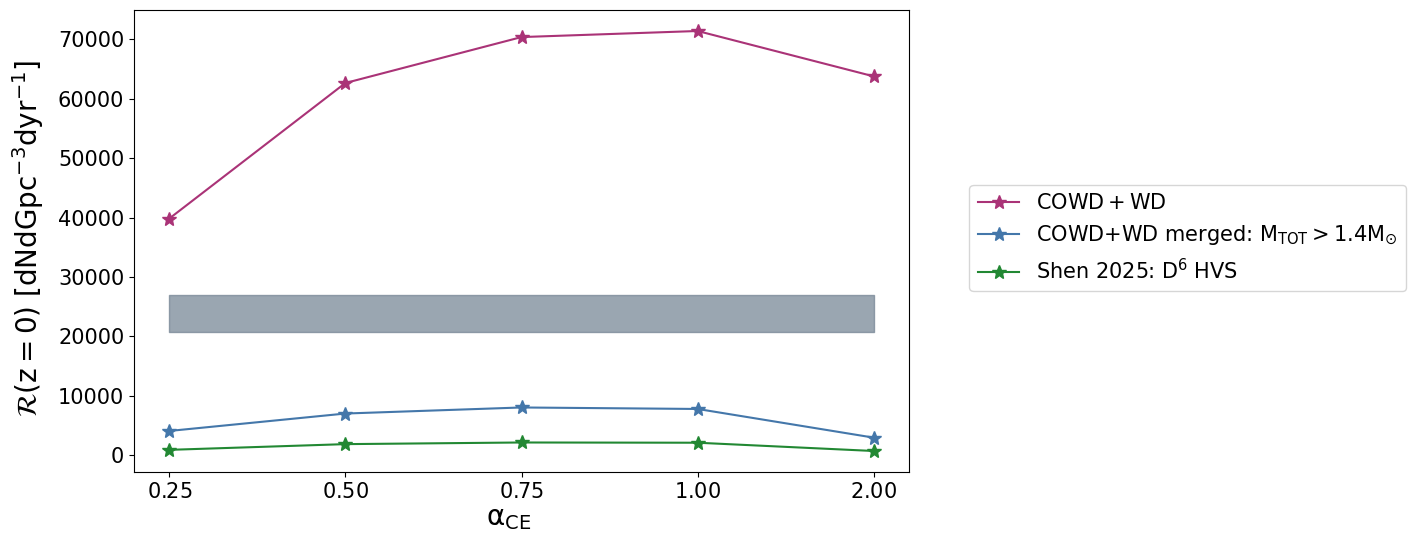

In [8]:
# we want all of the of SN to have the same color marker
markersize = 10
fig, ax = plt.subplots(1, 1, figsize = (10,6), sharex=True)
cset = tc.dark
cset_l = tc.light

x_positions = [0, 1, 2, 3, 4]
ax.plot(x_positions,cowdwd_SNe_Ia,'*', linestyle='-',label=r'$\mathrm{COWD + WD}$', color=cset_br.purple,markersize = markersize)
ax.plot(x_positions,mchan_SNe_Ia,'*', linestyle='-', label=r'COWD+WD merged: $\rm{M_{TOT}}>1.4\rm{M_{\odot}}$', color=cset_br.blue,markersize = markersize)
ax.plot(x_positions,rates_HVS,'*', linestyle='-', label='Shen 2025: $\mathrm{D^6}$ HVS', color=cset_br.green,markersize = markersize)

h_little = 0.6766

## Briel et al 2022 rates at z = 0
ax.fill_between([min(x_positions),max(x_positions)], 
                (0.77-0.10)*(10**5)*(h_little**3),
                (0.77+0.10)*(10**5)*(h_little**3), 
                alpha=0.70, 
                color="slategrey")

# axes labels 
# ax.set_yscale('log')
fig.supylabel(r"$\mathcal{R}$($\mathrm{z=0}$) [$\mathrm{dNdGpc^{-3}dyr^{-1}}$]",fontsize=20, x=0.001)
fig.supxlabel(r"$\mathrm{\alpha_{CE}}$", fontsize = 20)
fig.legend(loc='center left', bbox_to_anchor=(0.95, 0.5), fontsize=15)

ax.set_xticks(x_positions, [r"$\mathrm{0.25}$", r"$\mathrm{0.50}$", r"$\mathrm{0.75}$", r"$\mathrm{1.00}$", r"$\mathrm{2.00}$"], fontsize=15);

ax.tick_params(axis='y', labelsize=15);
# ax2.tick_params(labelbottom=True)

# ax.annotate("SN Ia Observations", xy=(4, 2.5*10**4), xytext=(4.25, 2*10**4), annotation_clip=False, fontsize=15, color = 'slategrey', arrowprops=dict(facecolor='slategrey', alpha=0.7,arrowstyle='->'))
